In [10]:
import pandas as pd
from utils.latex_tree_generator import equations_to_latex_forest

# Generate Latex tree code

In [11]:
equations = ["[0.13, x0 + 0.65]",
"[0.01*x0 + 0.07, 0.03*x0**4 + 0.16]",
"[0.03*x0 - 0.01, 0.10*x0**2 + 0.10]",
"[0.17*x0 - 0.14*x0**3, 0.20*x0**2*(0.01*x0 + 0.41) + 0.11]",
"[-0.98*x0**3 + x0, 0.09*x0**2 + 0.10]"]

In [12]:
for eq in equations:
    result = equations_to_latex_forest(eq.replace("x0", "x"), colors=["cyan", "orange"])
    drift_string, diffusion_string = eq.replace("**", "^").replace("x0", "x").replace("*", " ").strip("[").strip("]").split(",")
    print("\\dd x = (\\color{cyan}" + drift_string + "\\color{black})\\dd t + (\\color{orange}" + diffusion_string + "\\color{black}) \\dd W\n \\\\ \n", result)

\dd x = (\color{cyan}0.13\color{black})\dd t + (\color{orange} x + 0.65\color{black}) \dd W
 \\ 
 \begin{forest}
            for tree={
            edge path={
                \noexpand\path [\forestoption{edge}]
                (!u.parent anchor) -- +(0,-5pt) -| (.child anchor)\forestoption{edge label};
            },
            edge={line width=1pt},
            parent anchor=south,
            child anchor=north
            }
        [$0.13$, label={[xshift=-20pt,yshift=-12pt]}, text={cyan}]
\end{forest}
\quad
\begin{forest}
            for tree={
            edge path={
                \noexpand\path [\forestoption{edge}]
                (!u.parent anchor) -- +(0,-5pt) -| (.child anchor)\forestoption{edge label};
            },
            edge={line width=1pt},
            parent anchor=south,
            child anchor=north
            }
        [$+$, label={[xshift=-20pt,yshift=-12pt]}, text={orange}, for children={edge={orange}, text={orange}}
    [$0.65$, text={orange}]
    [$

# Generate samples

In [13]:
import jax
import jax.random as jr
import jax.numpy as jnp
import diffrax

def simulate(env, init_state, ts, process_noise_key):

    def drift(t, x, args):
        dx = env.drift(t, x, args)
        return dx
    
    def diffusion(t, x, args):
        return env.diffusion(t, x, args)

    brownian_motion = diffrax.UnsafeBrownianPath(shape=(env.n_var,), key=process_noise_key, levy_area=diffrax.SpaceTimeLevyArea) #define process noise
    system = diffrax.MultiTerm(diffrax.ODETerm(drift), diffrax.ControlTerm(diffusion, brownian_motion))

    sol = diffrax.diffeqsolve(
        system,
        diffrax.GeneralShARK(),
        t0=ts[0],
        t1=ts[-1],
        dt0=0.001,
        y0=init_state,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.DirectAdjoint(),
        max_steps = 16**5
    )

    ys = sol.ys
    return ys

def generate_data(key, env, dt, T, batch_size):
    key, init_key, p1_key, ts_key = jr.split(key, 4)

    ts = jnp.tile(jnp.arange(0, T, dt), (batch_size, 1))

    init_states = env.sample_init_states(batch_size, init_key)
    process_noise_keys = jr.split(p1_key, batch_size)

    ys = jax.vmap(simulate, in_axes=(None, 0, 0, 0))(env, init_states, ts, process_noise_keys)

    return ts, ys, process_noise_keys

import matplotlib.pyplot as plt

def plot_true_trajectory(ts, true_ys, state_idx=0, figsize=(8, 3), savepath=None):
    plt.figure(figsize=figsize)
    plt.plot(ts, true_ys[:, state_idx], color="black", linewidth=1.5)
    plt.axis("off")
    plt.tight_layout(pad=0)
    if savepath is not None:
        out_path = savepath if str(savepath).lower().endswith(".png") else f"{savepath}.png"
        plt.savefig(out_path, format="png", dpi=300, bbox_inches="tight", pad_inches=0)
    plt.show()

def plot_fitted_trajectory(ts, ys, true_ys, state_idx=0, figsize=(6, 5), savepath=None):
    plt.figure(figsize=figsize)
    plt.plot(ts, jnp.mean(ys[:, :, state_idx], axis=0), color="green", linewidth=1.5)
    plt.plot(ts, true_ys[0, :, state_idx], color="black", linewidth=1.5)
    plt.fill_between(ts,
                      ys[:, :, state_idx].mean(axis=0) - ys[:, :, state_idx].std(axis=0),
                      ys[:, :, state_idx].mean(axis=0) + ys[:, :, state_idx].std(axis=0),
                      alpha=0.4, facecolor="green")
    plt.axis("off")
    plt.ylim(-1.5, 1.5)
    plt.tight_layout(pad=0)
    if savepath is not None:
        out_path = savepath if str(savepath).lower().endswith(".png") else f"{savepath}.png"
        plt.savefig(out_path, format="png", dpi=300, bbox_inches="tight", pad_inches=0)
    plt.show()

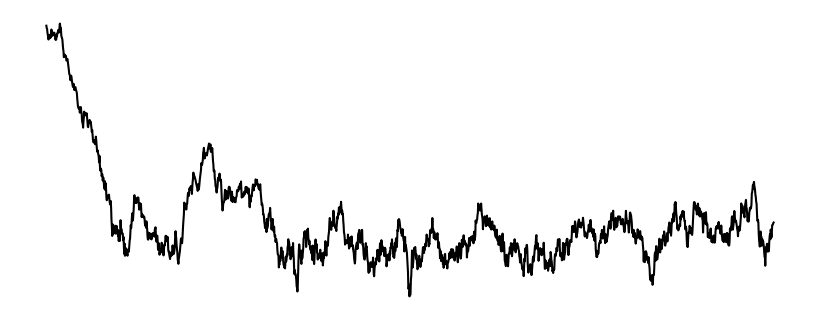

In [14]:
from utils.SDE_envs import DoubleWell

env = DoubleWell(0.1)
key = jr.PRNGKey(0)
key, subkey = jr.split(key)
batch_size = 5
ts, true_ys, noise_keys = generate_data(subkey, env, 0.01, 20, batch_size)

_equations = [[lambda x0: 0.133, lambda x0: x0 + 0.654],
                [lambda x0: 0.00837*x0 + 0.067, lambda x0: 0.0349*x0**4 + 0.155],
                [lambda x0: 0.0314*x0 - 0.00734, lambda x0: 0.0955*x0**2 + 0.098],
                [lambda x0: 0.169*x0 - 0.138*x0**3, lambda x0: 0.195*x0**2*(0.00998*x0 + 0.418) + 0.106],
                [lambda x0: -0.981*x0**3 + x0, lambda x0: 0.0943*x0**2 + 0.0977]]

plot_true_trajectory(ts[0], true_ys[0], savepath="../figures/animation/true_simulation")

In [15]:
def simulate_SDE(init_state, ts, process_noise_key, index):

    _drift ,_diffusion = _equations[index]

    def drift(t, x, args):
        dx = _drift(x)
        return jnp.atleast_1d(dx)
    
    def diffusion(t, x, args):
        return jnp.atleast_1d(_diffusion(x))
    
    brownian_motion = diffrax.UnsafeBrownianPath(shape=(1,), key=process_noise_key, levy_area=diffrax.SpaceTimeLevyArea) #define process noise
    system = diffrax.MultiTerm(diffrax.ODETerm(drift), diffrax.ControlTerm(diffusion, brownian_motion))

    sol = diffrax.diffeqsolve(
        system,
        diffrax.GeneralShARK(),
        t0=ts[0],
        t1=ts[-1],
        dt0=0.001,
        y0=init_state,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.DirectAdjoint(),
        max_steps = 16**5
    )

    ys = sol.ys
    return ys

def vmap_simulate(init_states, ts, process_noise_keys, index):
    return jax.vmap(simulate_SDE, in_axes=[None,0,0,None])(init_states, ts, process_noise_keys, index)

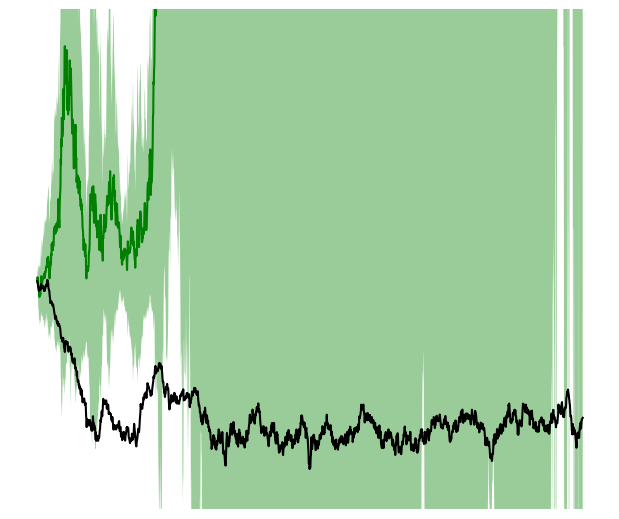

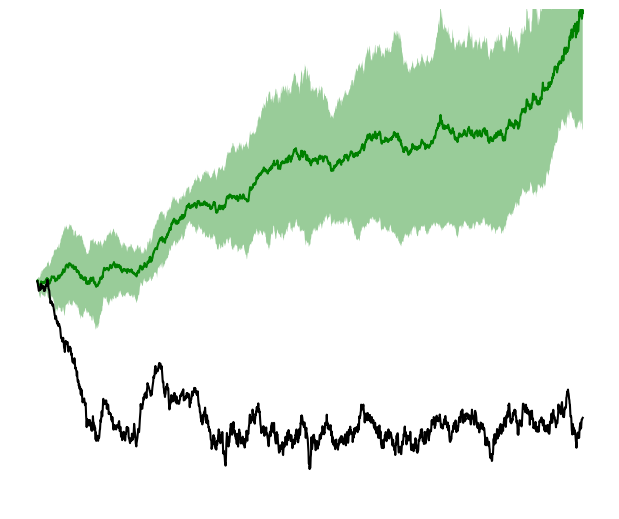

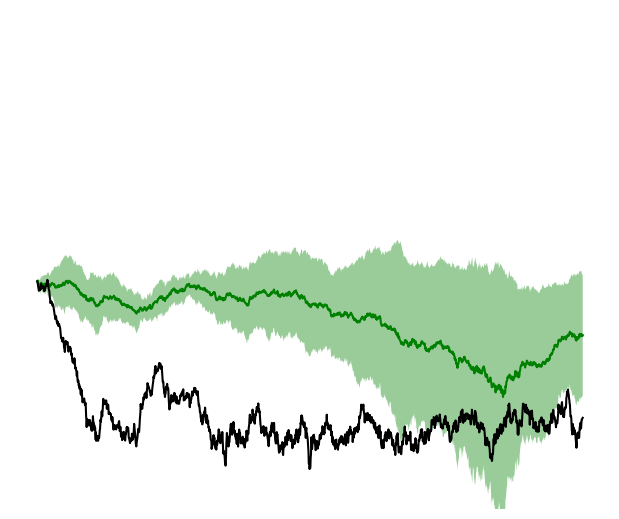

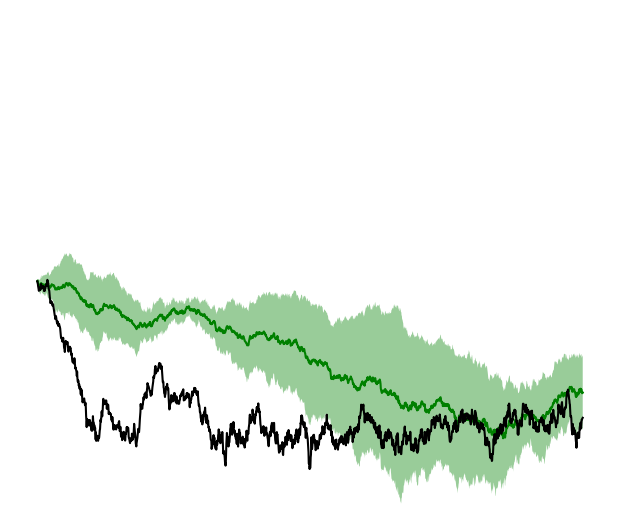

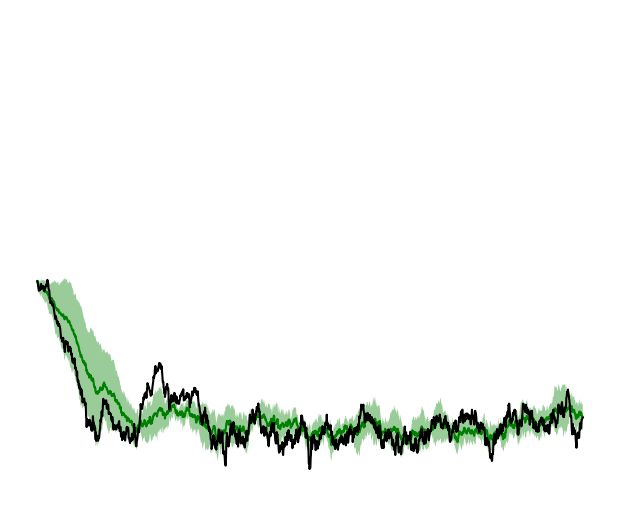

In [16]:
plot_fitted_trajectory(ts[0], vmap_simulate(true_ys[0,0], ts, noise_keys, 0), true_ys, savepath="../figures/animation/simulation1")
plot_fitted_trajectory(ts[0], vmap_simulate(true_ys[0,0], ts, noise_keys, 1), true_ys, savepath="../figures/animation/simulation2")
plot_fitted_trajectory(ts[0], vmap_simulate(true_ys[0,0], ts, noise_keys, 2), true_ys, savepath="../figures/animation/simulation3")
plot_fitted_trajectory(ts[0], vmap_simulate(true_ys[0,0], ts, noise_keys, 3), true_ys, savepath="../figures/animation/simulation4")
plot_fitted_trajectory(ts[0], vmap_simulate(true_ys[0,0], ts, noise_keys, 4), true_ys, savepath="../figures/animation/simulation5")

# Combine figures

Found target equation, 6 evolution steps, and 6 simulation results
✓ Saved: tree_evolution_with_simulations.gif
✓ Saved: tree_evolution_with_simulations.mp4


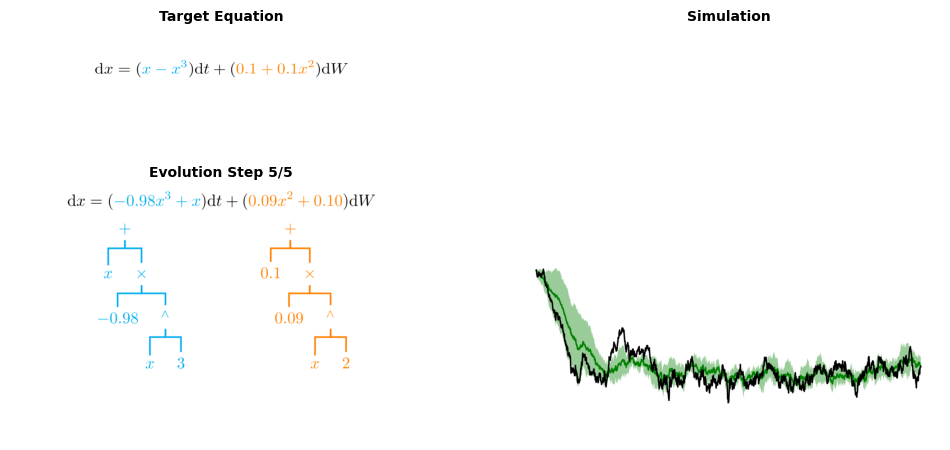

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.image as mpimg
import glob
import os
import numpy as np

# Create video with target equation (top-left), simulation (top-right), and evolving trees (bottom)
def create_evolution_video():
    # Load target equation image
    target_img = mpimg.imread('../figures/animation/target_equation.png')

    # Load tree evolution images
    tree_files = sorted([f for f in glob.glob('../figures/animation/tree*.png') if 'target' not in f])
    tree_images = [mpimg.imread(f) for f in tree_files]

    if len(tree_images) == 0:
        raise FileNotFoundError("No tree evolution images found in ../figures/animation/")

    # Load corresponding simulation images (simulation1.png through simulationN.png)
    sim_files = [f'../figures/animation/simulation{i+1}.png' for i in range(len(tree_images))]
    sim_files.append(sim_files[-1])
    tree_images.append(tree_images[-1])
    sim_images = [mpimg.imread(f) for f in sim_files if os.path.exists(f)]

    print(f"Found target equation, {len(tree_images)} evolution steps, and {len(sim_images)} simulation results")

    # Normalize tree images aligned by root nodes (top-center alignment)
    max_h = max(img.shape[0] for img in tree_images)
    max_w = max(img.shape[1] for img in tree_images)

    aligned_tree_images = []
    for img in tree_images:
        h, w = img.shape[:2]
        x_offset = (max_w - w) // 2
        bg = 1.0 if np.issubdtype(img.dtype, np.floating) else 255

        if img.ndim == 2:
            canvas = np.full((max_h, max_w), bg, dtype=img.dtype)
            canvas[:h, x_offset:x_offset + w] = img
        else:
            canvas = np.full((max_h, max_w, img.shape[2]), bg, dtype=img.dtype)
            canvas[:h, x_offset:x_offset + w, :] = img

        aligned_tree_images.append(canvas)

    # Layout: top-left target, top-right simulation (no title), bottom full-width evolution tree
    fig = plt.figure(figsize=(12, 6))
    ax_target = plt.subplot2grid((4, 2), (0, 0))
    ax_evolution = plt.subplot2grid((4, 2), (1, 0), rowspan=3)
    ax_sim = plt.subplot2grid((4, 2), (0, 1), rowspan=4)
    
    # Static target equation
    ax_target.imshow(target_img)
    ax_target.set_title("Target Equation", fontsize=10, fontweight='bold', pad=0)
    ax_target.axis('off')

    def animate(frame):
        idx = frame % len(aligned_tree_images)

        # Update evolving tree
        ax_evolution.clear()
        ax_evolution.imshow(aligned_tree_images[idx])
        ax_evolution.set_title(
            f"Evolution Step {np.minimum(idx + 1, 5)}/{np.minimum(len(aligned_tree_images),5)}",
            fontsize=10,
            fontweight='bold',
            pad=10
        )
        ax_evolution.axis('off')

        # Update simulation next to target equation (no title)
        ax_sim.clear()
        ax_sim.set_title("Simulation", fontsize=10, fontweight='bold', pad=42)
        ax_sim.imshow(sim_images[idx])
        ax_sim.axis('off')

        return []

    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=len(aligned_tree_images),
        interval=2000,
        repeat=True,
        blit=False
    )

    plt.rcParams['animation.ffmpeg_path'] ='/Users/sigur.de.vries/ffmpeg'
    FFwriter=animation.FFMpegWriter(fps=0.5, extra_args=['-vcodec', 'libx264'])
    anim.save('../figures/Supplementary_Figure_1.mp4', writer=FFwriter)

    # plt.tight_layout()
    plt.show()

    return anim

# Run the function
anim_obj = create_evolution_video()